# База идей для мероприятий VK Education

VK Education проводит форумы, олимпиады, хакатоны и карьерные дни для студентов. Задача проекта — собрать базу форматов, которые можно встроить в эти события, посчитать, сколько каждый стоит, и понять, с чего начинать.

**Что в ноутбуке**

1. Загрузка базы: 15 идей и построчные сметы.
2. Обзор: формат, аудитория, охват, бюджет.
3. Экономика: стоимость на одного участника.
4. Взвешенный скоринг по пяти критериям.
5. Матрица «ценность — стоимость» и три волны запуска.
6. Проверка устойчивости рейтинга к смене весов.

Данные лежат в `data/ideas.csv` и `data/costs.csv`. Цены — Москва, 2026 год, без НДС.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})
VK_BLUE, GREY = '#0077FF', '#A7B0BC'
pd.set_option('display.max_colwidth', 60)

ideas = pd.read_csv('data/ideas.csv')
costs = pd.read_csv('data/costs.csv')
print(ideas.shape, costs.shape)

(15, 14) (81, 3)


## 1. Что в базе

Каждая идея описана одинаково: формат, аудитория, площадка, охват, механика и референсы.

In [2]:
budget = costs.groupby('id')['cost_rub'].sum().rename('budget_rub')
df = ideas.merge(budget, on='id')
df['cost_per_person'] = (df['budget_rub'] / df['participants']).round()
df[['id', 'name', 'size', 'venue', 'participants', 'days', 'budget_rub']]

,id,name,size,venue,participants,days,budget_rub
0,1,Пол — это лава: баг-хант,Интерактивная зона,Зона 8×6 м на форуме или VK Fest,600,2,1055000
1,2,Колесо стека,Интерактивная зона,"Стенд 3×3 м на форуме, в вузе, на VK Fest",800,2,643000
2,3,Эскейп-рум «Инцидент в проде»,Интерактивная зона,Модульная комната 20 м² в офисе VK или на форуме,120,3,1050000
3,4,Лайв-код-ревью,Сценический формат,Зал на 150–300 мест в вузе-партнёре или офисе VK + транс...,250,1,645000
4,5,Промпт-баттл,Сценический формат,Главная сцена форума или VK Fest,316,1,650000
5,6,Собес-арена,Карьерный формат,Отдельная зона на форуме или опенспейс VK,500,1,400000
6,7,"Хакатон «Данные VK», 36 часов",Крупное событие,Лофт или коворкинг 1 000 м² в Москве + онлайн-трек для р...,200,2,5452000
7,8,VK Education City: квест-паспорт,Сквозная механика форума,"Вся площадка форума, 8 станций",3000,2,1940000
8,9,Ночь студенческих фейлов,Вечерний формат,Лофт или бар на 150–200 мест,200,1,850000
9,10,PowerPoint-караоке для айтишников,Вечерний формат,"Мини-сцена форума, вечерняя программа",162,1,260000


In [3]:
df.groupby('size').agg(идей=('id', 'count'),
                       охват=('participants', 'sum'),
                       бюджет_млн=('budget_rub', lambda s: round(s.sum() / 1e6, 2)))

,идей,охват,бюджет_млн
size,,,
Вечерний формат,2,362,1.11
Интерактивная зона,5,2570,3.86
Карьерный формат,1,500,0.40
Крупное событие,4,5150,22.69
Сквозная механика форума,1,3000,1.94
Сценический формат,2,566,1.30


## 2. Бюджеты

Разброс большой: PowerPoint-караоке обходится в 260 тыс. ₽, тур по шести городам — в 11,6 млн.

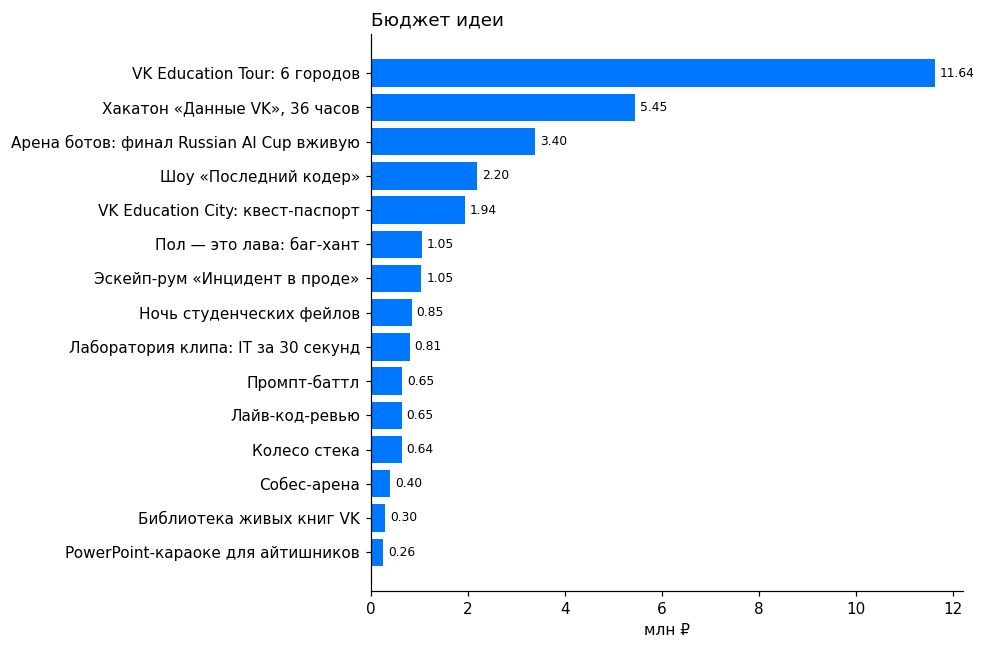

In [4]:
d = df.sort_values('budget_rub')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(d['name'], d['budget_rub'] / 1e6, color=VK_BLUE)
for y, v in enumerate(d['budget_rub'] / 1e6):
    ax.text(v + 0.1, y, f'{v:.2f}', va='center', fontsize=8)
ax.set_xlabel('млн ₽')
ax.set_title('Бюджет идеи', loc='left')
plt.tight_layout(); plt.show()

Из чего складывается смета у самой дорогой идеи в Москве — хакатона:

In [5]:
h = costs[costs.id == 7].sort_values('cost_rub', ascending=False).copy()
h['доля'] = (h.cost_rub / h.cost_rub.sum() * 100).round(1)
h[['item', 'cost_rub', 'доля']]

,item,cost_rub,доля
35,Призовой фонд,1500000,27.5
34,Питание: 240 человек × 4 800 ₽,1152000,21.1
33,"Площадка, 2 дня",900000,16.5
38,Мерч: 240 × 2 500 ₽,600000,11.0
39,Продвижение,400000,7.3
37,"Техника, сеть, электрика",400000,7.3
36,Режиссура и ведущий,250000,4.6
40,Зона отдыха и охрана,250000,4.6


## 3. Стоимость одного участника

Абсолютный бюджет мало говорит. Честнее смотреть, во сколько обходится один человек, который реально поиграл, послушал или прошёл собеседование.

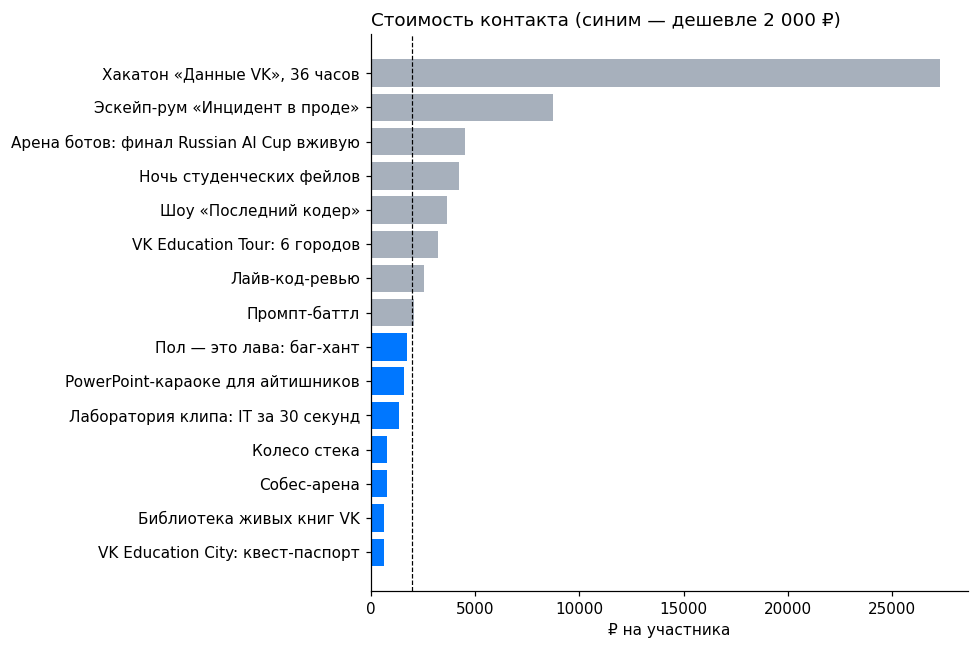

In [6]:
d = df.sort_values('cost_per_person')
fig, ax = plt.subplots(figsize=(9, 6))
colors = [VK_BLUE if v < 2000 else GREY for v in d['cost_per_person']]
ax.barh(d['name'], d['cost_per_person'], color=colors)
ax.axvline(2000, ls='--', c='k', lw=.8)
ax.set_xlabel('₽ на участника')
ax.set_title('Стоимость контакта (синим — дешевле 2 000 ₽)', loc='left')
plt.tight_layout(); plt.show()

## 4. Скоринг

Пять критериев, оценка от 1 до 5:

| Критерий | Вес | Что значит |
|---|---|---|
| Вовлечение | 0,25 | Хочется ли подойти и остаться |
| Связь с брендом VK | 0,20 | Работает ли на продукты и экосистему VK |
| Карьерная ценность | 0,25 | Ведёт ли к стажировкам и программам VK Education |
| Тиражируемость | 0,15 | Можно ли повторить в другом городе или вузе |
| Простота запуска | 0,15 | Сроки, подрядчики, риски |

Карьерной ценности дан такой же вес, как вовлечению: для VK Education мероприятие — вход в воронку образовательных программ, а не просто развлечение.

In [7]:
W = {'engagement': .25, 'brand': .20, 'career': .25, 'scalability': .15, 'ease': .15}
df['score'] = sum(df[k] * w for k, w in W.items()).round(2)
rank = df.sort_values(['score', 'cost_per_person'], ascending=[False, True])
rank[['name', *W, 'score', 'budget_rub', 'cost_per_person']].reset_index(drop=True)

,name,engagement,brand,career,scalability,ease,score,budget_rub,cost_per_person
0,Лайв-код-ревью,4,5,5,4,4,4.45,645000,2580.0
1,Библиотека живых книг VK,3,4,5,5,5,4.30,300000,667.0
2,Ночь студенческих фейлов,4,4,4,5,4,4.15,850000,4250.0
3,Колесо стека,4,4,3,5,5,4.05,643000,804.0
4,Собес-арена,3,4,5,4,4,4.00,400000,800.0
5,Шоу «Последний кодер»,5,5,4,3,2,4.00,2200000,3667.0
6,"Хакатон «Данные VK», 36 часов",4,5,5,3,2,4.00,5452000,27260.0
7,PowerPoint-караоке для айтишников,5,2,3,5,5,3.90,260000,1605.0
8,Эскейп-рум «Инцидент в проде»,5,5,3,4,2,3.90,1050000,8750.0
9,VK Education City: квест-паспорт,4,5,3,4,3,3.80,1940000,647.0


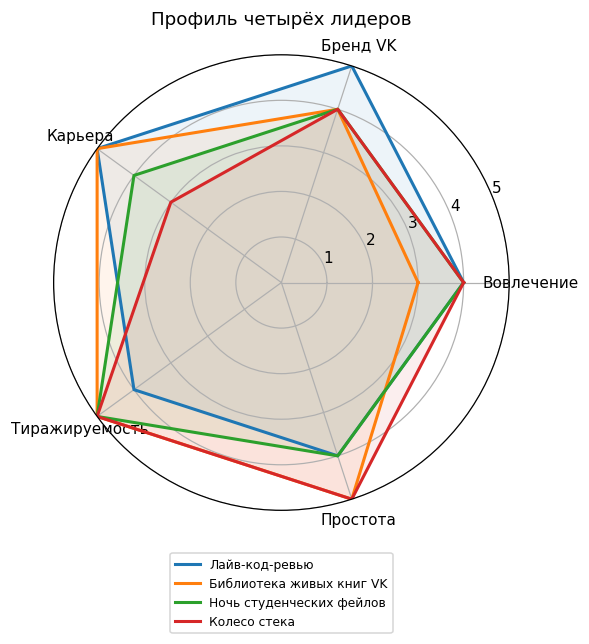

In [8]:
labels = ['Вовлечение', 'Бренд VK', 'Карьера', 'Тиражируемость', 'Простота']
top = rank.head(4)
ang = np.linspace(0, 2 * np.pi, 5, endpoint=False).tolist(); ang += ang[:1]
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for _, r in top.iterrows():
    v = [r[k] for k in W] + [r['engagement']]
    ax.plot(ang, v, lw=2, label=r['name']); ax.fill(ang, v, alpha=.08)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels); ax.set_ylim(0, 5)
ax.legend(loc='upper center', bbox_to_anchor=(.5, -.08), fontsize=8)
ax.set_title('Профиль четырёх лидеров', pad=20)
plt.tight_layout(); plt.show()

## 5. Ценность против стоимости

По горизонтали — стоимость участника (логарифмическая шкала), по вертикали — итоговый балл. Размер точки — охват.

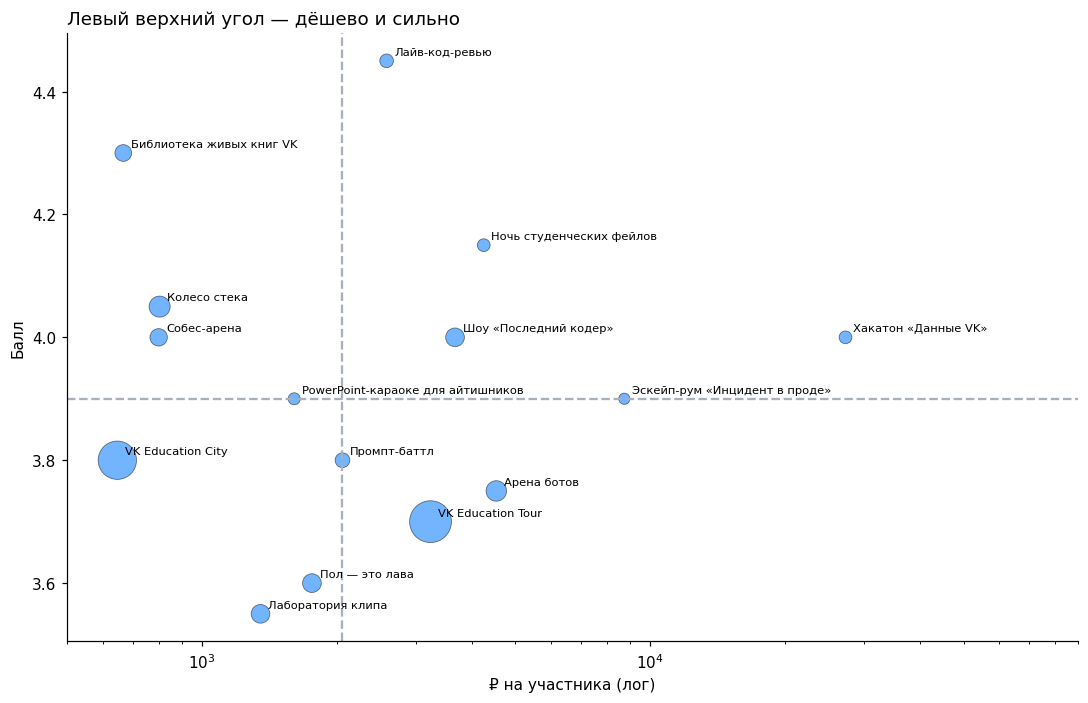

In [9]:
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(df.cost_per_person, df.score, s=df.participants / 5 + 30,
           c=VK_BLUE, alpha=.55, edgecolor='k', lw=.5)
for _, r in df.iterrows():
    ax.annotate(r['name'].split(':')[0].split(',')[0], (r.cost_per_person, r.score),
                fontsize=7.5, xytext=(5, 4), textcoords='offset points')
ax.set_xscale('log'); ax.set_xlim(500, 90000)
ax.axhline(df.score.median(), ls='--', c=GREY); ax.axvline(df.cost_per_person.median(), ls='--', c=GREY)
ax.set_xlabel('₽ на участника (лог)'); ax.set_ylabel('Балл')
ax.set_title('Левый верхний угол — дёшево и сильно', loc='left')
plt.tight_layout(); plt.show()

### Волны запуска

Правило простое:

- **Волна 1 — быстрые победы:** балл не ниже медианы и бюджет до 1 млн ₽. Запускаем в ближайший сезон.
- **Волна 2 — флагманы:** балл не ниже медианы, бюджет выше. Нужна подготовка 3–6 месяцев.
- **Волна 3 — усилители:** всё остальное. Добавляем в программу форумов по мере ресурсов.

In [10]:
med = df.score.median()
def wave(r):
    if r.score >= med and r.budget_rub <= 1_000_000: return '1. Быстрые победы'
    if r.score >= med: return '2. Флагманы'
    return '3. Усилители'
df['wave'] = df.apply(wave, axis=1)
w = df.sort_values(['wave', 'score'], ascending=[True, False])
w[['wave', 'name', 'score', 'budget_rub', 'participants']].reset_index(drop=True)

,wave,name,score,budget_rub,participants
0,1. Быстрые победы,Лайв-код-ревью,4.45,645000,250
1,1. Быстрые победы,Библиотека живых книг VK,4.30,300000,450
2,1. Быстрые победы,Ночь студенческих фейлов,4.15,850000,200
3,1. Быстрые победы,Колесо стека,4.05,643000,800
4,1. Быстрые победы,Собес-арена,4.00,400000,500
5,1. Быстрые победы,PowerPoint-караоке для айтишников,3.90,260000,162
6,2. Флагманы,"Хакатон «Данные VK», 36 часов",4.00,5452000,200
7,2. Флагманы,Шоу «Последний кодер»,4.00,2200000,600
8,2. Флагманы,Эскейп-рум «Инцидент в проде»,3.90,1050000,120
9,3. Усилители,Промпт-баттл,3.80,650000,316


In [11]:
w.groupby('wave').agg(идей=('id', 'count'), охват=('participants', 'sum'),
                     бюджет_млн=('budget_rub', lambda s: round(s.sum() / 1e6, 2)))

,идей,охват,бюджет_млн
wave,,,
1. Быстрые победы,6,2362,3.1
2. Флагманы,3,920,8.7
3. Усилители,6,8866,19.5


## 6. Устойчивость рейтинга

Веса выбраны экспертно, поэтому проверим, не держится ли рейтинг на них. 5 000 раз случайно перераспределяем веса (распределение Дирихле) и считаем, как часто идея попадает в топ-5.

In [12]:
rng = np.random.default_rng(42)
M = df[list(W)].values
hits = np.zeros(len(df))
for _ in range(5000):
    s = M @ rng.dirichlet(np.ones(5))
    hits[np.argsort(-s)[:5]] += 1
df['top5_share'] = (hits / 5000 * 100).round(1)
df.sort_values('top5_share', ascending=False)[['name', 'score', 'top5_share']].head(8).reset_index(drop=True)

,name,score,top5_share
0,Лайв-код-ревью,4.45,91.3
1,Библиотека живых книг VK,4.30,77.3
2,Ночь студенческих фейлов,4.15,68.2
3,Колесо стека,4.05,61.4
4,PowerPoint-караоке для айтишников,3.90,48.1
5,Собес-арена,4.00,31.3
6,"Хакатон «Данные VK», 36 часов",4.00,26.6
7,Шоу «Последний кодер»,4.00,23.2


## Выводы

- Лидеры по баллу — **Лайв-код-ревью**, **Библиотека живых книг** и **Ночь студенческих фейлов**. Все три недорогие и прямо ведут к карьерной воронке VK.
- Самый дешёвый контакт дают сквозной квест-паспорт, Библиотека живых книг, Собес-арена и Колесо стека: 650–810 ₽ на человека.
- Хакатон — самый дорогой в пересчёте на участника (около 27 тыс. ₽), но в нём больше всего кандидатов на стажировку. Его стоит оценивать по конверсии в найм, а не по охвату.
- **Пол — это лава** и **Колесо фортуны** из задания хороши как магниты для зоны, но карьерной ценности у них мало. Их место — рядом с Собес-ареной или Библиотекой, чтобы поток людей шёл дальше.
- Рейтинг устойчив: при случайных весах Лайв-код-ревью попадает в топ-5 в 91% случаев, Библиотека — в 77%, Ночь фейлов — в 68%, Колесо стека — в 61%. Первая волна от выбора весов почти не зависит.